# Quantum-hardware step — the LUCJ generator on IBM Heron
### Stage 1, step 2 of *"Amortized magic-steered quantum generative models for CI subspaces"*

**What this notebook does.** It executes the **LUCJ quantum generative circuit** on a *real* IBM Quantum
processor, samples electronic configurations on-chip, applies IBM's self-consistent configuration recovery
(S-CoRe) and sample-based quantum diagonalization (SQD), and compares the resulting energy against a
device-noise-free simulation of the *same* circuit and against exact FCI. The prepared quantum state **is**
the generative model over Slater determinants; here the chip does the generation.

**System.** N$_2$ at $R=2.0$\,Å, CAS(10e,12o)/cc-pVDZ → $2\times12=24$ qubits. We chose $R=2.0$ because our
classical simulation sweep across the dissociation curve showed this is the geometry where the CCSD-seeded
LUCJ generator most clearly beats the cheap classical prior while the CCSD seed is still reliable — i.e. we
spend real QPU time where the quantum generator demonstrably helps.

**Honest scope.** This is a *demonstration on real hardware plus a quantification of the noise gap*, not a
quantum-advantage claim. Every number is measured or computed; nothing is asserted that the numbers do not show.

**Method & citations.** SQD + self-consistent configuration recovery: Robledo-Moreno *et al.*, *Sci. Adv.* **11**,
eadu9991 (2025), arXiv:2405.05068. QSCI: Kanno *et al.*, *Phys. Rev. Research* (2023), arXiv:2302.11320.
LUCJ ansatz: Motta, Sung, Whaley, Head-Gordon, Shee, *Electron. Struct.* (2023). Software: `ffsim`,
`qiskit-addon-sqd`, Qiskit Runtime. Hardware-execution pattern adapted from the QGSS 2026 Lab 4c.

> **Account.** `QiskitRuntimeService()` loads the IBM Quantum account already saved in this Colab environment
> (the same one used in the QGSS labs). Your token is never printed or stored by this notebook.

## 0. Install dependencies

In [ ]:
%pip install -q qiskit qiskit-ibm-runtime qiskit-aer qiskit-addon-sqd ffsim pyscf pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.8/742.8 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.

## 1. Imports

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

import pyscf, pyscf.cc, pyscf.mcscf, pyscf.ao2mo
import ffsim

from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler

from qiskit_addon_sqd.fermion import diagonalize_fermionic_hamiltonian, SCIResult

## 2. Molecule, active space and exact references
We build the CAS(10e,12o) active-space Hamiltonian and compute Hartree–Fock and exact FCI energies. All
subspace energies below are scored with **these same** active-space integrals, so every comparison is on one
consistent metric.

In [ ]:
R = 2.0
mol = pyscf.gto.Mole()
mol.build(atom=[['N', (0,0,0)], ['N', (R,0,0)]], basis='cc-pvdz', symmetry=False)

n_frozen = 2
NCAS = 12
active_space = range(n_frozen, n_frozen + NCAS)

mf = pyscf.scf.RHF(mol).run()
n_electrons = 10
num_elec_a = num_elec_b = 5
nelec = (num_elec_a, num_elec_b)
num_orbitals = NCAS

cas = pyscf.mcscf.CASCI(mf, num_orbitals, nelec)
mo = cas.sort_mo(list(active_space), base=0)
hcore, e_core = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

e_fci = cas.kernel(mo)[0]
e_hf = float(mf.e_tot)
print(f'orbitals={num_orbitals}  qubits={2*num_orbitals}  nelec={nelec}')
print(f'E_HF  = {e_hf:.6f} Ha')
print(f'E_FCI = {e_fci:.6f} Ha   (correlation {1000*(e_fci-e_hf):.1f} mHa)')

converged SCF energy = -108.33058275366
CASCI E = -108.808041897588  E(CI) = -25.9565485320792  S^2 = 0.0000031
orbitals=12  qubits=24  nelec=(5, 5)
E_HF  = -108.330583 Ha
E_FCI = -108.808042 Ha   (correlation -477.5 mHa)


## 3. The LUCJ quantum generator
CCSD-seeded local unitary cluster-Jastrow ansatz with heavy-hex-friendly interaction pairs (Lab-4c pattern).
The circuit prepares Hartree–Fock, applies the LUCJ unitary, and measures — its Born distribution over
bitstrings is the generative model over determinants.

In [ ]:
ccsd = pyscf.cc.CCSD(mf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]).run(max_cycle=1000)
t1, t2 = ccsd.t1, ccsd.t2

n_reps = 2
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices  = [(p, p) for p in range(0, num_orbitals, 4)]   # heavy-hex-local subset

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t1=t1, t2=t2, n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
    optimize=True, options=dict(maxiter=20),
)

qubits = QuantumRegister(2 * num_orbitals, name='q')
circuit = QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()
print('LUCJ circuit built:', 2*num_orbitals, 'qubits, n_reps =', n_reps)

E(CCSD) = -108.835399199255  E_corr = -0.5048164455953558
LUCJ circuit built: 24 qubits, n_reps = 2


## 4. One SQD driver, used for every sample source
We wrap IBM's high-level self-consistent-recovery + SQD routine so the *identical* post-processing is applied
to noiseless-simulation samples and to real-hardware samples — the only difference between the two runs is
where the bitstrings came from.

In [ ]:
def run_sqd(bit_array, label, max_iterations=5, samples_per_batch=300, num_batches=5, seed=142):
    history = []
    def cb(results):
        e = min(r.energy for r in results) + e_core
        history.append(e)
        print(f'  [{label}] iter {len(history)}: E = {e:.6f} Ha   (dE = {1000*(e-e_fci):.1f} mHa)')
    result = diagonalize_fermionic_hamiltonian(
        hcore, eri, bit_array,
        samples_per_batch=samples_per_batch, norb=num_orbitals, nelec=nelec,
        num_batches=num_batches, max_iterations=max_iterations,
        symmetrize_spin=True, seed=seed, callback=cb,
    )
    e_tot = result.energy + e_core
    print(f'[{label}] final  E = {e_tot:.6f} Ha   dE = {1000*(e_tot-e_fci):.1f} mHa')
    return e_tot, history

# NOTE: if your installed qiskit-addon-sqd predates diagonalize_fermionic_hamiltonian,
# use the manual solve_sci_batch + recover_configurations loop from QGSS Lab 4c instead.

## 5. Noiseless reference — the *same* circuit, no device noise
A statevector simulation of the transpiled circuit gives the device-noise-free baseline. (24 qubits is well
within reach of a statevector simulator.) This isolates *how much* real-hardware noise costs us.

In [ ]:
sim_backend = AerSimulator()
pm_sim = generate_preset_pass_manager(optimization_level=1, backend=sim_backend)
isa_sim = pm_sim.run(circuit)
SHOTS = 10000
job_sim = AerSampler().run([isa_sim], shots=SHOTS)
bit_array_sim = job_sim.result()[0].data.meas
print('noiseless samples:', bit_array_sim.num_shots)
e_sim, hist_sim = run_sqd(bit_array_sim, 'noiseless-sim')

noiseless samples: 10000
  [noiseless-sim] iter 1: E = -108.775387 Ha   (dE = 32.7 mHa)
  [noiseless-sim] iter 2: E = -108.779408 Ha   (dE = 28.6 mHa)
  [noiseless-sim] iter 3: E = -108.779547 Ha   (dE = 28.5 mHa)
  [noiseless-sim] iter 4: E = -108.779547 Ha   (dE = 28.5 mHa)
[noiseless-sim] final  E = -108.779547 Ha   dE = 28.5 mHa


## 5b. IBM credentials — paste your token ONCE (required for the real QPU)
Colab wipes saved accounts every session, so paste your IBM token here once and run this cell.
**Security:** after it works, clear these two values (or comment the lines) so your token does NOT stay in the file.

In [ ]:
# Get these at https://quantum.cloud.ibm.com  (API token + your instance CRN).
token    = "<YOUR_IBM_QUANTUM_TOKEN>"
instance = "<YOUR_IBM_QUANTUM_INSTANCE_CRN>"   # <YOUR_IBM_QUANTUM_INSTANCE_CRN>
QiskitRuntimeService.save_account(token=token, instance=instance, overwrite=True, set_as_default=True)
svc = QiskitRuntimeService(); bk = svc.backends()
print(f'Account OK \u2014 {len(bk)} backend(s) available:')
for b in bk[:6]:
    print('  ', b.name, b.num_qubits, 'qubits')

Account OK — 3 backend(s) available:
   ibm_fez 156 qubits
   ibm_marrakesh 156 qubits
   ibm_kingston 156 qubits


## 6. Connect to IBM Quantum and select a Heron device
Loads the account saved in cell 5b. If it is missing, run 5b (with your token) first, then re-run this cell.

In [ ]:
try:
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=2*num_orbitals)
    print('Connected to REAL backend:', backend.name)
except Exception as err:
    from qiskit_ibm_runtime.fake_provider import FakeKingston
    print(f'No IBM account / real device found ({err}).')
    print('>>> Run cell 5b with your IBM token, then re-run THIS cell to reach the real QPU. <<<')
    print('For now falling back to FakeKingston (noisy simulator, NOT real hardware) so the notebook still completes.')
    backend = FakeKingston()
print('backend:', backend.name)

Connected to REAL backend: ibm_marrakesh
backend: ibm_marrakesh


## 7. Transpile the LUCJ circuit for the device
`ffsim.qiskit.PRE_INIT` inserts the fermionic-swap-aware passes that keep the LUCJ two-qubit-gate count low on
heavy-hex hardware (the same trick used in the IBM SQD demonstrations).

In [ ]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
pm.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pm.run(circuit)
print('transpiled gate counts:', dict(isa_circuit.count_ops()))
print('two-qubit depth:', isa_circuit.depth(lambda instr: len(instr.qubits) == 2))

transpiled gate counts: {'sx': 2936, 'rz': 2748, 'cz': 853, 'x': 45, 'measure': 24, 'barrier': 1}
two-qubit depth: 165


## 8. Run on the real QPU
A few seconds of QPU time plus queue. **Write down the printed `job_id`** — if the kernel dies you can recover
the results with `service.job(job_id)` instead of spending QPU time again.

In [ ]:
sampler = RuntimeSampler(mode=backend)
job = sampler.run([isa_circuit], shots=SHOTS)
job_id = job.job_id()
print('submitted job:', job_id)

submitted job: d9qe731dsedc73af67d0


In [ ]:
# (Re-)load the hardware results. Safe to re-run after a kernel restart:
#   job = service.job('PASTE_JOB_ID_HERE')
result_hw = job.result()[0]
bit_array_hw = result_hw.data.meas
print('hardware samples:', bit_array_hw.num_shots)
e_hw, hist_hw = run_sqd(bit_array_hw, 'hardware')

hardware samples: 10000
  [hardware] iter 1: E = -108.778902 Ha   (dE = 29.1 mHa)
  [hardware] iter 2: E = -108.802167 Ha   (dE = 5.9 mHa)
  [hardware] iter 3: E = -108.804861 Ha   (dE = 3.2 mHa)
  [hardware] iter 4: E = -108.806467 Ha   (dE = 1.6 mHa)
  [hardware] iter 5: E = -108.806854 Ha   (dE = 1.2 mHa)
[hardware] final  E = -108.806854 Ha   dE = 1.2 mHa


## 9. Compare: chip vs noiseless sim vs FCI (honest)
The recovery+SQD loop is variational, so every energy is an upper bound to FCI ($\Delta E \ge 0$). We report
the real-hardware energy, the device-noise-free energy of the same circuit, and the exact FCI reference —
and the *noise gap* between chip and sim.

source                                  E (Ha)    dE (mHa)
exact FCI                          -108.808042         0.0
noiseless sim (same circuit)       -108.779547        28.5
IBM hardware (this run)            -108.806854         1.2

noise gap (hardware - sim) = -27.3 mHa


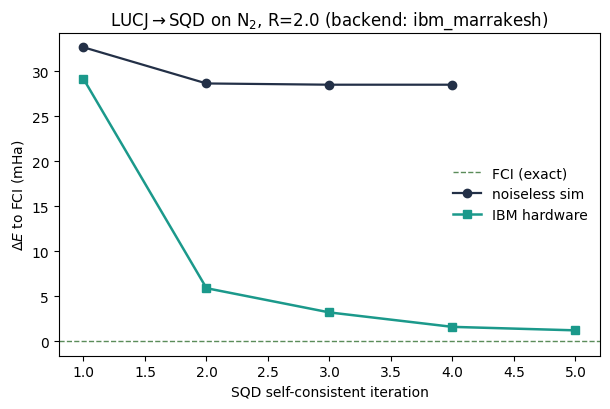

saved hw_lucj_n2_result.json


In [ ]:
import json
rows = [('exact FCI', e_fci, 0.0),
        ('noiseless sim (same circuit)', e_sim, 1000*(e_sim-e_fci)),
        ('IBM hardware (this run)', e_hw, 1000*(e_hw-e_fci))]
print(f"{'source':32s}{'E (Ha)':>14s}{'dE (mHa)':>12s}")
for name, e, de in rows:
    print(f'{name:32s}{e:14.6f}{de:12.1f}')
print(f'\nnoise gap (hardware - sim) = {1000*(e_hw-e_sim):.1f} mHa')

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.axhline(0, color='#5B8C5A', ls='--', lw=1, label='FCI (exact)')
ax.plot(range(1, len(hist_sim)+1), [1000*(e-e_fci) for e in hist_sim], '-o',
        color='#233047', lw=1.6, label='noiseless sim')
ax.plot(range(1, len(hist_hw)+1),  [1000*(e-e_fci) for e in hist_hw],  '-s',
        color='#1B998B', lw=1.8, label='IBM hardware')
ax.set_xlabel('SQD self-consistent iteration'); ax.set_ylabel(r'$\Delta E$ to FCI (mHa)')
ax.set_title(f'LUCJ$\\to$SQD on N$_2$, R=2.0 (backend: {backend.name})')
ax.legend(frameon=False); fig.tight_layout(); plt.show()

json.dump({'R': R, 'e_fci': e_fci, 'e_hf': e_hf, 'e_sim': e_sim, 'e_hw': e_hw,
           'backend': backend.name, 'shots': SHOTS, 'job_id': job_id,
           'hist_sim': hist_sim, 'hist_hw': hist_hw}, open('hw_lucj_n2_result.json','w'), indent=1)
print('saved hw_lucj_n2_result.json')

## 10. Save the result to your Google Drive
So it can be picked up automatically. Approve the one-time Drive mount prompt.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('hw_lucj_n2_result.json', '/content/drive/MyDrive/hw_lucj_n2_result.json')
print('Saved hw_lucj_n2_result.json to your Google Drive (MyDrive).')

Mounted at /content/drive
Saved hw_lucj_n2_result.json to your Google Drive (MyDrive).


## 11. Hardware energy error bar (seed sweep — NO new QPU time)
Re-run the SQD recovery on the **same cached hardware counts** (`bit_array_hw`) with several random seeds. The seed-to-seed spread of the recovered energy is a legitimate error bar on the hardware number, with **zero new device time**. Also re-saves `hw_lucj_n2_result.json` with `dE_mean_mHa`, `dE_std_mHa`.

In [ ]:
# --- Hardware energy error bar: seed sweep on the SAME cached counts (NO new QPU time) ---
import json, numpy as np
seeds = [142, 7, 23, 88, 101, 256, 314, 777]
e_seeds = []
for s in seeds:
    e_s, _ = run_sqd(bit_array_hw, f'hw-seed{s}', seed=s)   # reuses the SAME hardware bit_array
    e_seeds.append(float(e_s))
e_seeds = np.array(e_seeds)
dE = 1000.0 * (e_seeds - e_fci)
print('
=== HARDWARE ENERGY ERROR BAR (n=%d recovery seeds, cached counts, no new QPU) ===' % len(seeds))
print('dE = %.2f +/- %.2f mHa   (best %.2f, worst %.2f)' % (dE.mean(), dE.std(), dE.min(), dE.max()))
try:
    d = json.load(open('hw_lucj_n2_result.json'))
    d.update({'e_hw_seeds': e_seeds.tolist(), 'recovery_seeds': seeds,
              'e_hw_mean': float(e_seeds.mean()), 'e_hw_std': float(e_seeds.std()),
              'dE_mean_mHa': float(dE.mean()), 'dE_std_mHa': float(dE.std())})
    json.dump(d, open('hw_lucj_n2_result.json','w'), indent=1)
    print('updated hw_lucj_n2_result.json with the error bar')
except Exception as e:
    print('(could not re-save json:', e, ') -- just copy the dE line above')
